In [73]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [74]:
# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_excel("data1319.xlsx")

/Users/charlesyamamura/ls/envs/mlenv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [75]:
# -----------------------------
# 2. Temporal train-test split
# -----------------------------
train_df = df[df['year'] <= 2018].copy()
test_df  = df[df['year'] == 2019].copy()

In [76]:
def split_xy(data):
    X = data.drop(columns=['year', 'mo', 'model', 'share'])
    y = data['share'].values.reshape(-1, 1)
    return X, y

In [77]:
X_train, y_train = split_xy(train_df)
X_test, y_test   = split_xy(test_df)

In [78]:
# -----------------------------
# 3. Scaling
# -----------------------------
input_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [79]:
X_train = input_scaler.fit_transform(X_train)
X_test  = input_scaler.transform(X_test)

In [80]:
y_train = target_scaler.fit_transform(y_train)
y_test  = target_scaler.transform(y_test)

In [81]:
# -----------------------------
# 4. Neural Network Definition
# -----------------------------
input_size = X_train.shape[1]
hidden_size = 8
dropout_rate = 0.1

In [82]:
model = Sequential([
    Dense(hidden_size, input_shape=(input_size,)),
    LeakyReLU(),
    Dropout(dropout_rate),
    Dense(1)
])

/Users/charlesyamamura/ls/envs/mlenv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [83]:
# -----------------------------
# 5. Loss and Optimizer
# -----------------------------
optimizer = Adam(learning_rate=0.001, decay=1e-4)
model.compile(optimizer=optimizer, loss='mse')

/Users/charlesyamamura/ls/envs/mlenv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [84]:
# -----------------------------
# 6. Training
# -----------------------------
num_epochs = 150
batch_size = 10

In [85]:
history = model.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3472
Epoch 2/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1872
Epoch 3/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1407
Epoch 4/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0970
Epoch 5/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0782
Epoch 6/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0677
Epoch 7/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0506
Epoch 8/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0449
Epoch 9/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0390
Epoch 10/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0355
Epoch 11/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0329
Epoch 12/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0282
Epoch 13/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0266
Epoch 14/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0223
Epoch 15/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0208


In [86]:
# -----------------------------
# 7. Predictions & Performance
# -----------------------------
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [87]:
train_pred_inv = target_scaler.inverse_transform(train_pred)
test_pred_inv  = target_scaler.inverse_transform(test_pred)

In [88]:
train_r2 = r2_score(target_scaler.inverse_transform(y_train), train_pred_inv)
test_r2  = r2_score(target_scaler.inverse_transform(y_test), test_pred_inv)

In [89]:
print("\nPerformance Results:")
print("Training R2:", train_r2)
print("Testing R2:", test_r2)


Performance Results:
Training R2: 0.8549033622684609
Testing R2: 0.4465778054339862


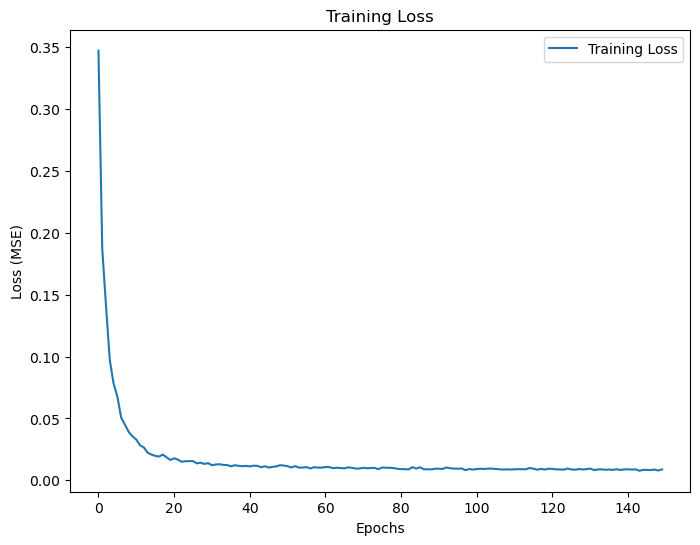

In [90]:
# -----------------------------
# 8. Plot training loss
# -----------------------------
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.legend()
plt.show()